In [1]:
import os
os.chdir("..") # Ek folder piche jane ke liye
print(os.getcwd()) # Check karein ke ab path 'psl_ai_platform' par hai ya nahi

c:\Users\User\Desktop\psl_ai_platform


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("reports/eda/injury/rolling_workload/bowler_rolling_workload_features.csv")
df.head()

,match_id,match_date,bowler,balls_bowled,runs_conceded,wickets_taken,overs_bowled,balls_last_7_days,balls_last_14_days,matches_last_7_days,matches_last_14_days,days_since_last_match,back_to_back_match,short_recovery_flag,overs_last_7_days,overs_last_14_days,fatigue_signal_score,high_recent_workload_flag,high_match_density_flag,high_fatigue_flag
0,1211672,2020-11-14,A Lyth,6,4,0,1.00,0,0,0,0,NaN,0,0,0.0,0.0,0.0,False,False,False
1,1211675,2020-11-15,A Lyth,13,22,0,2.17,6,6,1,1,1.0,1,1,1.0,1.0,8.5,False,False,False
2,1527553,2026-03-27,A Zampa,24,26,0,4.00,0,0,0,0,NaN,0,0,0.0,0.0,0.0,False,False,False
3,1527557,2026-03-29,A Zampa,24,12,0,4.00,24,24,1,1,2.0,0,1,4.0,4.0,11.5,False,False,True
4,1527561,2026-04-02,A Zampa,25,28,0,4.17,48,48,2,2,4.0,0,0,8.0,8.0,19.0,True,False,True


In [4]:
feature_cols = [
    "balls_bowled",
    "overs_bowled",
    "balls_last_7_days",
    "balls_last_14_days",
    "matches_last_7_days",
    "matches_last_14_days",
    "days_since_last_match",
    "back_to_back_match",
    "short_recovery_flag",
    "overs_last_7_days",
    "overs_last_14_days",
    "fatigue_signal_score",
]
corr_df = df[feature_cols].corr()
corr_df

,balls_bowled,overs_bowled,balls_last_7_days,balls_last_14_days,matches_last_7_days,matches_last_14_days,days_since_last_match,back_to_back_match,short_recovery_flag,overs_last_7_days,overs_last_14_days,fatigue_signal_score
balls_bowled,1.000000,0.999998,0.206717,0.207765,0.125806,0.124815,-0.030809,0.037123,0.051316,0.206718,0.207768,0.188112
overs_bowled,0.999998,1.000000,0.206758,0.207808,0.125842,0.124861,-0.030888,0.037168,0.051348,0.206759,0.207812,0.188159
balls_last_7_days,0.206717,0.206758,1.000000,0.820769,0.950742,0.771536,-0.410110,0.289224,0.454671,1.000000,0.820775,0.978540
balls_last_14_days,0.207765,0.207808,0.820769,1.000000,0.790038,0.963106,-0.401465,0.186286,0.319014,0.820768,1.000000,0.872376
matches_last_7_days,0.125806,0.125842,0.950742,0.790038,1.000000,0.812811,-0.446118,0.298846,0.478232,0.950752,0.790045,0.955581
matches_last_14_days,0.124815,0.124861,0.771536,0.963106,0.812811,1.000000,-0.430263,0.188884,0.327340,0.771543,0.963107,0.846392
days_since_last_match,-0.030809,-0.030888,-0.410110,-0.401465,-0.446118,-0.430263,1.000000,-0.151493,-0.270347,-0.410129,-0.401479,-0.443838
back_to_back_match,0.037123,0.037168,0.289224,0.186286,0.298846,0.188884,-0.151493,1.000000,0.565065,0.289231,0.186286,0.401619
short_recovery_flag,0.051316,0.051348,0.454671,0.319014,0.478232,0.327340,-0.270347,0.565065,1.000000,0.454691,0.319024,0.549813
overs_last_7_days,0.206718,0.206759,1.000000,0.820768,0.950752,0.771543,-0.410129,0.289231,0.454691,1.000000,0.820773,0.978545


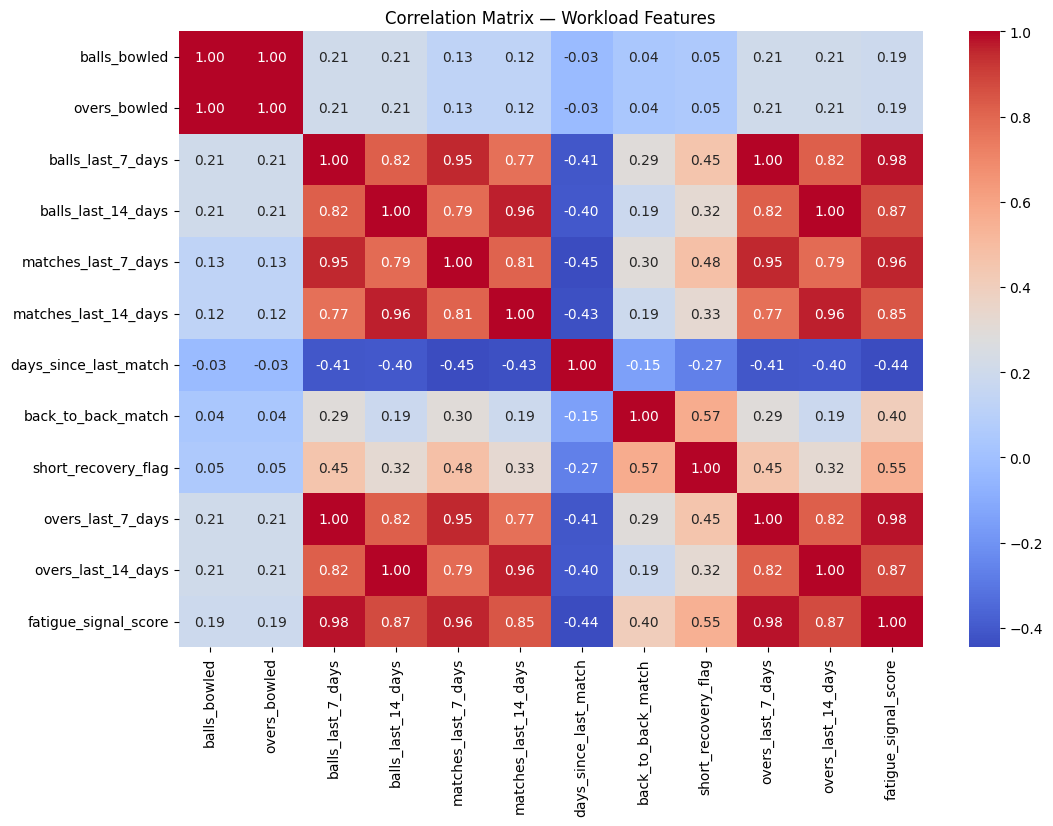

In [5]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix — Workload Features")
plt.show()

In [6]:
proxy_df = pd.read_csv("reports/eda/injury/proxy_target/injury_proxy_dataset.csv")
proxy_df.head()

,match_id,match_date,bowler,balls_bowled,runs_conceded,wickets_taken,overs_bowled,balls_last_7_days,balls_last_14_days,matches_last_7_days,...,days_since_last_match,back_to_back_match,short_recovery_flag,overs_last_7_days,overs_last_14_days,fatigue_signal_score,high_recent_workload_flag,high_match_density_flag,high_fatigue_flag,injury_proxy_event
0,1211672,2020-11-14,A Lyth,6,4,0,1.00,0,0,0,...,NaN,0,0,0.0,0.0,0.0,False,False,False,0
1,1211675,2020-11-15,A Lyth,13,22,0,2.17,6,6,1,...,1.0,1,1,1.0,1.0,8.5,False,False,False,0
2,1527553,2026-03-27,A Zampa,24,26,0,4.00,0,0,0,...,NaN,0,0,0.0,0.0,0.0,False,False,False,0
3,1527557,2026-03-29,A Zampa,24,12,0,4.00,24,24,1,...,2.0,0,1,4.0,4.0,11.5,False,False,True,0
4,1527561,2026-04-02,A Zampa,25,28,0,4.17,48,48,2,...,4.0,0,0,8.0,8.0,19.0,True,False,True,0


In [7]:
proxy_df["injury_proxy_event"].value_counts(dropna=False)

injury_proxy_event
0    3673
1     257
Name: count, dtype: int64

In [8]:
proxy_df[proxy_df["injury_proxy_event"] == 1].head(20)

,match_id,match_date,bowler,balls_bowled,runs_conceded,wickets_taken,overs_bowled,balls_last_7_days,balls_last_14_days,matches_last_7_days,...,days_since_last_match,back_to_back_match,short_recovery_flag,overs_last_7_days,overs_last_14_days,fatigue_signal_score,high_recent_workload_flag,high_match_density_flag,high_fatigue_flag,injury_proxy_event
16,959221,2016-02-23,AD Russell,24,37,0,4.00,48,124,2,...,2.0,0,1,8.00,20.67,27.00,True,True,True,1
23,1168829,2019-02-22,AD Russell,12,28,0,2.00,55,55,3,...,2.0,0,1,9.17,9.17,24.84,True,True,True,1
38,1416503,2024-03-15,AJ Hosein,24,35,0,4.00,73,97,3,...,3.0,0,0,12.17,16.17,30.34,True,True,True,1
94,1076003,2017-02-25,Aamer Yamin,24,39,0,4.00,50,50,2,...,1.0,1,1,8.33,8.33,24.66,True,False,True,1
147,1416482,2024-02-25,Abbas Afridi,27,34,0,4.50,94,94,4,...,2.0,0,1,15.67,15.67,39.34,True,True,True,1
162,1475269,2025-05-22,Abbas Afridi,24,51,0,4.00,49,49,2,...,3.0,0,0,8.17,8.17,19.34,True,False,True,1
186,1416503,2024-03-15,Abrar Ahmed,24,32,0,4.00,72,97,3,...,3.0,0,0,12.00,16.17,30.00,True,True,True,1
198,1475271,2025-05-25,Abrar Ahmed,24,28,0,4.00,48,48,2,...,4.0,0,0,8.00,8.00,19.00,True,False,True,1
229,1247021,2021-02-28,Ahmed Daniyal,27,37,0,4.50,70,70,3,...,2.0,0,1,11.67,11.67,29.84,True,True,True,1
235,1247038,2021-06-18,Ahmed Daniyal,18,24,0,3.00,57,108,3,...,1.0,1,1,9.50,18.00,31.50,True,True,True,1
